## Exercise 6

### Part 1

In [ ]:
import numpy as np
import math
from scipy.stats import chi2

# Set parameters
A = 8  # Offered traffic
m = 10  #Number of lines
N = 100000  # MH samples
burn_in = 5000  #Burn-in


# Target distribution
def target_probs(A, m):
    w = np.array([A**i / math.factorial(i) for i in range(m+1)])
    return w / w.sum()


p = target_probs(A, m)

# Metropolis-hastings sampler
def mh():

    x = 0
    samples = []

    for t in range(N + burn_in):

        # Symmetric proposal with rejection at boundaries
        y = x + np.random.choice([-1, 1])

        if y < 0 or y > m:
            y = x

        # MH ratio
        log_px = x * np.log(A) - math.log(math.factorial(x))
        log_py = y * np.log(A) - math.log(math.factorial(y))

        alpha = min(1, np.exp(log_py - log_px))

        if np.random.rand() < alpha:
            x = y

        if t >= burn_in:
            samples.append(x)

    return np.array(samples)


samples = mh()

obs = np.bincount(samples, minlength=m+1)
exp = N * p


# Chi square test
chi2_stat = np.sum((obs - exp)**2 / exp)

df = m
crit = chi2.ppf(0.95, df)

print("Chi-square:", chi2_stat)
print("Critical:", crit)
print("Pass" if chi2_stat < crit else "Fail")


# Compare with theoretical values
print("\nstate | theory | empirical")
for i in range(m+1):
    print(i, p[i], obs[i]/obs.sum())

Chi-square: 16.650179222809147
Critical: 18.307038053275146
Pass

state | theory | empirical
0 0.00041116370815887153 0.00027
1 0.0032893096652709722 0.00342
2 0.013157238661083889 0.01303
3 0.03508596976289037 0.03599
4 0.07017193952578074 0.07029
5 0.11227510324124919 0.11088
6 0.14970013765499893 0.14937
7 0.17108587160571304 0.17009
8 0.17108587160571304 0.16945
9 0.1520763303161894 0.15345
10 0.12166106425295149 0.12376


### Part 2

In [ ]:
# Set parameters
A1 = 4
A2 = 4
m = 10
N = 100000
burn_in = 5000

# Target distribution
states = [(i, j) for i in range(m+1) for j in range(m+1) if i + j <= m]

def target_prob(i, j):
    return (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))

weights = np.array([target_prob(i, j) for (i, j) in states])
Z = weights.sum()
probs = weights / Z


# Map state to index
state_to_idx = {s: k for k, s in enumerate(states)}


# (a) Metropolis-hastings
def mh():

    i, j = 0, 0
    samples = []

    for t in range(N + burn_in):

        # Propose move in 4 directions
        di, dj = 0, 0
        move = np.random.choice(["i+", "i-", "j+", "j-"])

        if move == "i+":
            di = 1
        elif move == "i-":
            di = -1
        elif move == "j+":
            dj = 1
        else:
            dj = -1

        i_new, j_new = i + di, j + dj

        # Reject invalid states
        if i_new < 0 or j_new < 0 or i_new + j_new > m:
            i_new, j_new = i, j

        # MH acceptance ratio
        log_p_old = i * np.log(A1) - math.log(math.factorial(i)) \
                  + j * np.log(A2) - math.log(math.factorial(j))

        log_p_new = i_new * np.log(A1) - math.log(math.factorial(i_new)) \
                  + j_new * np.log(A2) - math.log(math.factorial(j_new))

        alpha = min(1, np.exp(log_p_new - log_p_old))

        if np.random.rand() < alpha:
            i, j = i_new, j_new

        if t >= burn_in:
            samples.append((i, j))

    return samples


# (b) Coordinate-wise metropolis-hastings
def coord_mh():

    i, j = 0, 0
    samples = []

    for t in range(N + burn_in):

        # Update i given j
        i_new = i + np.random.choice([-1, 1])
        if i_new < 0 or i_new + j > m:
            i_new = i

        log_pi = i * np.log(A1) - math.log(math.factorial(i))
        log_pnew = i_new * np.log(A1) - math.log(math.factorial(i_new))

        alpha = min(1, np.exp(log_pnew - log_pi))

        if np.random.rand() < alpha:
            i = i_new

        # Update j given i
        j_new = j + np.random.choice([-1, 1])
        if j_new < 0 or i + j_new > m:
            j_new = j

        log_pj = j * np.log(A2) - math.log(math.factorial(j))
        log_pnew = j_new * np.log(A2) - math.log(math.factorial(j_new))

        alpha = min(1, np.exp(log_pnew - log_pj))

        if np.random.rand() < alpha:
            j = j_new

        if t >= burn_in:
            samples.append((i, j))

    return samples


# (c) Gibbs sampling
def truncated_poisson_sample(A, max_k):
    # Sample from truncated Poisson via inversion
    probs = np.array([A**k / math.factorial(k) for k in range(max_k+1)])
    probs = probs / probs.sum()
    return np.random.choice(len(probs), p=probs)


def gibbs():

    i, j = 0, 0
    samples = []

    for t in range(N + burn_in):

        # sample i | j
        max_i = m - j
        i = truncated_poisson_sample(A1, max_i)

        # sample j | i
        max_j = m - i
        j = truncated_poisson_sample(A2, max_j)

        if t >= burn_in:
            samples.append((i, j))

    return samples



In [82]:
# Metropolis-hastings results
samples = mh()


# Chi square test
obs = np.zeros(len(states))

for s in samples:
    obs[state_to_idx[s]] += 1

exp = N * probs

chi2_stat = np.sum((obs - exp)**2 / exp)

df = len(states) - 1

crit = chi2.ppf(0.95, df)

print("Chi-square:", chi2_stat)
print("Critical:", crit)
print("PASS" if chi2_stat < crit else "FAIL")


# Results
print("\n(i, j) | theory | empirical")
print("-"*40)

emp = obs / obs.sum()

for k, (i, j) in enumerate(states[:15]):  # Print first 15 states
    print(f"{(i,j)} | {probs[k]:.5f} | {emp[k]:.5f}")

Chi-square: 121.97529235239801
Critical: 84.82064549765667
FAIL

(i, j) | theory | empirical
----------------------------------------
(0, 0) | 0.00041 | 0.00032
(0, 1) | 0.00164 | 0.00155
(0, 2) | 0.00329 | 0.00344
(0, 3) | 0.00439 | 0.00453
(0, 4) | 0.00439 | 0.00438
(0, 5) | 0.00351 | 0.00297
(0, 6) | 0.00234 | 0.00238
(0, 7) | 0.00134 | 0.00160
(0, 8) | 0.00067 | 0.00063
(0, 9) | 0.00030 | 0.00025
(0, 10) | 0.00012 | 0.00007
(1, 0) | 0.00164 | 0.00158
(1, 1) | 0.00658 | 0.00637
(1, 2) | 0.01316 | 0.01330
(1, 3) | 0.01754 | 0.01769


In [87]:
# Coordinate-wise metropolis-hastings results
samples = coord_mh()


# Chi square test
obs = np.zeros(len(states))

for s in samples:
    obs[state_to_idx[s]] += 1

exp = N * probs

chi2_stat = np.sum((obs - exp)**2 / exp)

df = len(states) - 1

crit = chi2.ppf(0.95, df)

print("Chi-square:", chi2_stat)
print("Critical:", crit)
print("PASS" if chi2_stat < crit else "FAIL")


# Results
print("\n(i, j) | theory | empirical")
print("-"*40)

emp = obs / obs.sum()

for k, (i, j) in enumerate(states[:15]):  # Print first 15 states
    print(f"{(i,j)} | {probs[k]:.5f} | {emp[k]:.5f}")

Chi-square: 135.2215801793412
Critical: 84.82064549765667
FAIL

(i, j) | theory | empirical
----------------------------------------
(0, 0) | 0.00041 | 0.00051
(0, 1) | 0.00164 | 0.00159
(0, 2) | 0.00329 | 0.00301
(0, 3) | 0.00439 | 0.00405
(0, 4) | 0.00439 | 0.00409
(0, 5) | 0.00351 | 0.00330
(0, 6) | 0.00234 | 0.00249
(0, 7) | 0.00134 | 0.00143
(0, 8) | 0.00067 | 0.00063
(0, 9) | 0.00030 | 0.00027
(0, 10) | 0.00012 | 0.00006
(1, 0) | 0.00164 | 0.00171
(1, 1) | 0.00658 | 0.00641
(1, 2) | 0.01316 | 0.01254
(1, 3) | 0.01754 | 0.01729


In [89]:
# Gibbs results
samples = gibbs()


# Chi square test
obs = np.zeros(len(states))

for s in samples:
    obs[state_to_idx[s]] += 1

exp = N * probs

chi2_stat = np.sum((obs - exp)**2 / exp)

df = len(states) - 1

crit = chi2.ppf(0.95, df)

print("Chi-square:", chi2_stat)
print("Critical:", crit)
print("PASS" if chi2_stat < crit else "FAIL")


# Results
print("\n(i, j) | theory | empirical")
print("-"*40)

emp = obs / obs.sum()

for k, (i, j) in enumerate(states[:15]):  # Print first 15 states
    print(f"{(i,j)} | {probs[k]:.5f} | {emp[k]:.5f}")

Chi-square: 58.29749148407512
Critical: 84.82064549765667
PASS

(i, j) | theory | empirical
----------------------------------------
(0, 0) | 0.00041 | 0.00052
(0, 1) | 0.00164 | 0.00181
(0, 2) | 0.00329 | 0.00332
(0, 3) | 0.00439 | 0.00443
(0, 4) | 0.00439 | 0.00446
(0, 5) | 0.00351 | 0.00372
(0, 6) | 0.00234 | 0.00239
(0, 7) | 0.00134 | 0.00142
(0, 8) | 0.00067 | 0.00077
(0, 9) | 0.00030 | 0.00034
(0, 10) | 0.00012 | 0.00016
(1, 0) | 0.00164 | 0.00163
(1, 1) | 0.00658 | 0.00614
(1, 2) | 0.01316 | 0.01345
(1, 3) | 0.01754 | 0.01724


### Part 3


n = 10
True θ, ψ: 3.044263169489084 2.882806123362061
Posterior mean θ: 3.49621683087482
Posterior mean ψ: 2.35944110007793

n = 100
True θ, ψ: 2.534658546829606 3.4179455705829596
Posterior mean θ: 2.433637181150963
Posterior mean ψ: 2.735593976289302

n = 1000
True θ, ψ: 2.210950298265829 0.7765883864504464
Posterior mean θ: 2.2051043675652666
Posterior mean ψ: 0.8448318869931503


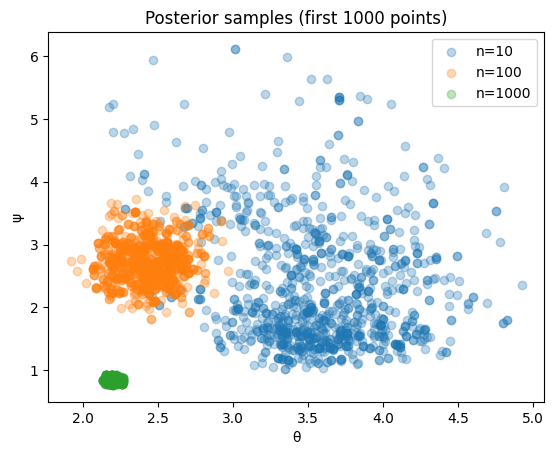

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Set parameters
rho = 0.5
Sigma = np.array([[1, rho],
                  [rho, 1]])

n_values = [10, 100, 1000]
N = 50000
burn_in = 5000


# Prior sampling
def sample_prior():
    xi, gamma = np.random.multivariate_normal([0, 0], Sigma)
    theta = np.exp(xi)
    psi = np.exp(gamma)
    return theta, psi


# Generate data
def generate_data(theta, psi, n):
    return np.random.normal(theta, np.sqrt(psi), n)


# Log prior of (θ, ψ)
def log_prior(theta, psi):
    if theta <= 0 or psi <= 0:
        return -np.inf

    x = np.log(theta)
    y = np.log(psi)

    det = 1 - rho**2
    quad = (x**2 - 2*rho*x*y + y**2) / (2*det)

    # Jacobian: 1/(θ ψ)
    return -np.log(theta) - np.log(psi) - quad


# Log likelihood
def log_likelihood(data, theta, psi):
    if psi <= 0:
        return -np.inf

    n = len(data)
    return -0.5*n*np.log(2*np.pi*psi) - np.sum((data - theta)**2) / (2*psi)


# Log posterior (up to constant)
def log_posterior(data, theta, psi):
    return log_likelihood(data, theta, psi) + log_prior(theta, psi)


# Metropolis-hastings sampler
# Random walk in (log θ, log ψ)
def mh_sampler(data):

    # Work in log-space for positivity
    x, y = np.log(np.mean(data)), np.log(np.var(data) + 1e-3)

    samples = []

    for t in range(N + burn_in):

        # Propose in log space
        x_new = x + np.random.normal(0, 0.1)
        y_new = y + np.random.normal(0, 0.1)

        theta, psi = np.exp(x), np.exp(y)
        theta_new, psi_new = np.exp(x_new), np.exp(y_new)

        log_p_old = log_posterior(data, theta, psi)
        log_p_new = log_posterior(data, theta_new, psi_new)

        if np.random.rand() < min(1, np.exp(log_p_new - log_p_old)):
            x, y = x_new, y_new

        if t >= burn_in:
            samples.append((np.exp(x), np.exp(y)))

    return np.array(samples)


# Run experiment for different n
results = {}

for n in n_values:

    print("\n==============================")
    print("n =", n)
    print("==============================")

    # Prior sample
    theta_true, psi_true = sample_prior()

    # Generate data
    data = generate_data(theta_true, psi_true, n)

    # Posterior sampling
    samples = mh_sampler(data)

    theta_samples = samples[:, 0]
    psi_samples = samples[:, 1]

    # Summaries
    theta_mean = np.mean(theta_samples)
    psi_mean = np.mean(psi_samples)

    print("True θ, ψ:", theta_true, psi_true)
    print("Posterior mean θ:", theta_mean)
    print("Posterior mean ψ:", psi_mean)

    results[n] = (theta_samples, psi_samples)


# Visualization
plt.figure()

for n in n_values:
    theta_samples, psi_samples = results[n]
    plt.scatter(theta_samples[:1000], psi_samples[:1000], alpha=0.3, label=f"n={n}")

plt.xlabel("θ")
plt.ylabel("ψ")
plt.legend()
plt.title("Posterior samples (first 1000 points)")
plt.show()

This plot shows how the joint posterior distribution of the mean and variance becomes increasingly concentrated as the amount of observed data increases.